In [2]:

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler 


first autoencoder

In [3]:
# Carga de datos
data = r"C:\Users\belen\OneDrive\Escritorio\TFM ISA\DATA_eCOLI.xlsx"
df = pd.read_excel(data)

latent_dim = 8
capa_int=19

In [3]:
# Estandarización
scaler = StandardScaler() 
X = scaler.fit_transform(df).astype("float32")
input_dim = X.shape[1]

inputs = tf.keras.Input(shape=(input_dim,))

# Encoder
x = layers.Dense(capa_int, activation="tanh")(inputs)
    
# Cuello    
x = layers.Dense(latent_dim, activation="tanh", name="latent")(x)
        
# Decoder
x = layers.Dense(capa_int, activation="tanh")(x)

outputs = layers.Dense(input_dim, activation="linear")(x)

# Modelo 
autoencoder = tf.keras.Model(inputs, outputs)
autoencoder.compile(optimizer="adamW", loss="mse")

# entrenamiento y Error
autoencoder.fit(X, X, epochs=200, batch_size=256, shuffle=True, verbose=0)
mse = autoencoder.evaluate(X, X, verbose=0)
print(f"MSE del Autoencoder: {mse:.5f}")

MSE del Autoencoder: 0.06913



Activation Function: tanh
Run 01/20 -> MSE = 0.060942
Run 02/20 -> MSE = 0.061544
Run 03/20 -> MSE = 0.063310
Run 04/20 -> MSE = 0.061070
Run 05/20 -> MSE = 0.071223
Run 06/20 -> MSE = 0.061787
Run 07/20 -> MSE = 0.059735
Run 08/20 -> MSE = 0.063091
Run 09/20 -> MSE = 0.069830
Run 10/20 -> MSE = 0.062129
Run 11/20 -> MSE = 0.062879
Run 12/20 -> MSE = 0.073807
Run 13/20 -> MSE = 0.065340
Run 14/20 -> MSE = 0.074587
Run 15/20 -> MSE = 0.064528
Run 16/20 -> MSE = 0.068299
Run 17/20 -> MSE = 0.067096
Run 18/20 -> MSE = 0.066048
Run 19/20 -> MSE = 0.060996
Run 20/20 -> MSE = 0.069093

Activation Function: sigmoid
Run 01/20 -> MSE = 0.109445
Run 02/20 -> MSE = 0.100812
Run 03/20 -> MSE = 0.111973
Run 04/20 -> MSE = 0.109342
Run 05/20 -> MSE = 0.108005
Run 06/20 -> MSE = 0.104217
Run 07/20 -> MSE = 0.110278
Run 08/20 -> MSE = 0.107827
Run 09/20 -> MSE = 0.106549
Run 10/20 -> MSE = 0.103871
Run 11/20 -> MSE = 0.105421
Run 12/20 -> MSE = 0.105915
Run 13/20 -> MSE = 0.108502
Run 14/20 -> MSE = 

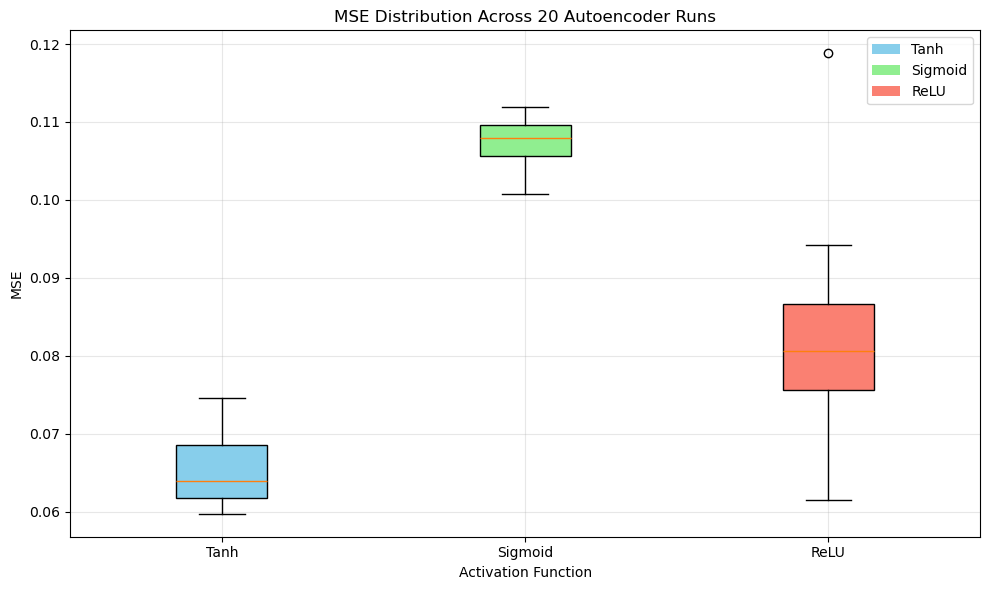

In [6]:
from matplotlib.patches import Patch

scaler = StandardScaler()
X = scaler.fit_transform(df).astype("float32")
input_dim = X.shape[1]

n_runs = 20
epochs = 200
batch_size = 256

activations = ["tanh", "sigmoid", "relu"]

results = {}

# TRAINING



for activation in activations:

    mse_list = []

    print("\n" + "=" * 50)
    print(f"Activation Function: {activation}")
    print("=" * 50)

    for run in range(n_runs):

        
        inputs = tf.keras.Input(shape=(input_dim,))

        # Encoder
        x = layers.Dense(
            capa_int,
            activation=activation
        )(inputs)

        # Latent space
        x = layers.Dense(
            latent_dim,
            activation=activation,
            name="latent"
        )(x)

        # Decoder
        x = layers.Dense(
            capa_int,
            activation=activation
        )(x)

        outputs = layers.Dense(
            input_dim,
            activation="linear"
        )(x)

        autoencoder = tf.keras.Model(inputs, outputs)

        autoencoder.compile(
            optimizer="adamW",
            loss="mse"
        )


        # TRAINING


        autoencoder.fit(
            X,
            X,
            epochs=epochs,
            batch_size=batch_size,
            shuffle=True,
            verbose=0
        )

        mse = autoencoder.evaluate(
            X,
            X,
            verbose=0
        )

        mse_list.append(mse)

        print(
            f"Run {run+1:02d}/{n_runs} "
            f"-> MSE = {mse:.6f}"
        )

    results[activation] = mse_list


# BOXPLOT

colors = [
    "skyblue",      # tanh
    "lightgreen",   # sigmoid
    "salmon"        # relu
]

plt.figure(figsize=(10, 6))

bp = plt.boxplot(
    [results[a] for a in activations],
    tick_labels=["Tanh", "Sigmoid", "ReLU"],
    patch_artist=True
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

legend_elements = [
    Patch(facecolor="skyblue", label="Tanh"),
    Patch(facecolor="lightgreen", label="Sigmoid"),
    Patch(facecolor="salmon", label="ReLU")
]

plt.legend(handles=legend_elements)

plt.ylabel("MSE")
plt.xlabel("Activation Function")
plt.title("MSE Distribution Across 20 Autoencoder Runs")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



 **selecting dimension of intermedite and latent**


Latent dimension = 7
Hidden=10 | MSE=0.1273 ± 0.0066
Hidden=11 | MSE=0.1212 ± 0.0074
Hidden=12 | MSE=0.1142 ± 0.0084
Hidden=13 | MSE=0.1114 ± 0.0101
Hidden=14 | MSE=0.1018 ± 0.0073
Hidden=15 | MSE=0.0994 ± 0.0097
Hidden=16 | MSE=0.0957 ± 0.0089
Hidden=17 | MSE=0.0952 ± 0.0049
Hidden=18 | MSE=0.0909 ± 0.0061
Hidden=19 | MSE=0.0879 ± 0.0085

Latent dimension = 8
Hidden=10 | MSE=0.1117 ± 0.0051
Hidden=11 | MSE=0.1019 ± 0.0058
Hidden=12 | MSE=0.0934 ± 0.0076
Hidden=13 | MSE=0.0857 ± 0.0082
Hidden=14 | MSE=0.0806 ± 0.0099
Hidden=15 | MSE=0.0759 ± 0.0088
Hidden=16 | MSE=0.0730 ± 0.0069
Hidden=17 | MSE=0.0665 ± 0.0052
Hidden=18 | MSE=0.0653 ± 0.0056
Hidden=19 | MSE=0.0652 ± 0.0056


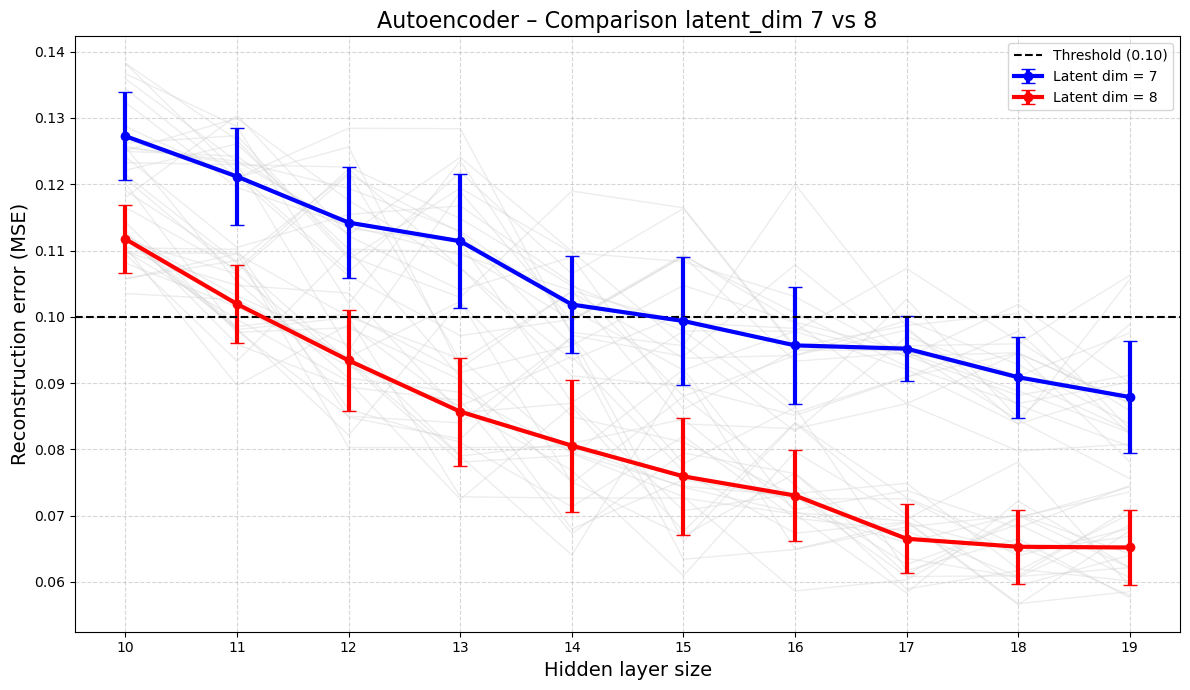

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(df).astype("float32")
input_dim = X.shape[1]

tries = 20
latent_dims = [7, 8]
capas_int = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


# AUTOENCODER


def mse_autoencoder_2_capas(input_dim, capa_int, latent_dim):

    inputs = tf.keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(
        capa_int,
        activation="tanh"
    )(inputs)

    x = layers.Dense(
        latent_dim,
        activation="tanh",
        name="latent"
    )(x)

    # Decoder
    x = layers.Dense(
        capa_int,
        activation="tanh"
    )(x)

    outputs = layers.Dense(
        input_dim,
        activation="linear"
    )(x)

    autoencoder = tf.keras.Model(inputs, outputs)

    autoencoder.compile(
        optimizer="adamW",
        loss="mse"
    )

    autoencoder.fit(
        X,
        X,
        epochs=200,
        batch_size=256,
        shuffle=True,
        verbose=0
    )

    mse = autoencoder.evaluate(
        X,
        X,
        verbose=0
    )

    return mse

resultados_runs = {ld: [] for ld in latent_dims}
resultados_mean = {ld: [] for ld in latent_dims}
resultados_std = {ld: [] for ld in latent_dims}

for ld in latent_dims:

    print(f"\nLatent dimension = {ld}")

    for capa in capas_int:

        errores = []

        for t in range(tries):

            mse = mse_autoencoder_2_capas(
                input_dim=input_dim,
                capa_int=capa,
                latent_dim=ld
            )

            errores.append(mse)

        resultados_runs[ld].append(errores)

        resultados_mean[ld].append(
            np.mean(errores)
        )

        resultados_std[ld].append(
            np.std(errores, ddof=1)
        )

        print(
            f"Hidden={capa:2d} | "
            f"MSE={np.mean(errores):.4f} ± "
            f"{np.std(errores, ddof=1):.4f}"
        )

# PLOT


plt.figure(figsize=(12, 7))

colors = {
    7: "blue",
    8: "red"
}

# Gray trajectories (individual runs)


for ld in latent_dims:

    for run in range(tries):

        ys = [
            resultados_runs[ld][i][run]
            for i in range(len(capas_int))
        ]

        plt.plot(
            capas_int,
            ys,
            color="lightgray",
            alpha=0.4,
            linewidth=1
        )

for ld in latent_dims:

    plt.errorbar(
        capas_int,
        resultados_mean[ld],
        yerr=resultados_std[ld],
        fmt='o-',
        color=colors[ld],
        linewidth=3,
        markersize=6,
        capsize=5,
        label=f"Latent dim = {ld}"
    )

plt.axhline(
    y=0.10,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Threshold (0.10)'
)


plt.xlabel(
    "Hidden layer size",
    fontsize=14
)

plt.ylabel(
    "Reconstruction error (MSE)",
    fontsize=14
)

plt.title(
    "Autoencoder – Comparison latent_dim 7 vs 8",
    fontsize=16
)

plt.xticks(capas_int)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.legend()

plt.tight_layout()

plt.show()

 **duplicate for 100 tries**

Hidden layer = 14
Hidden layer = 15
Hidden layer = 16
Hidden layer = 17
Hidden layer = 18
Hidden layer = 19


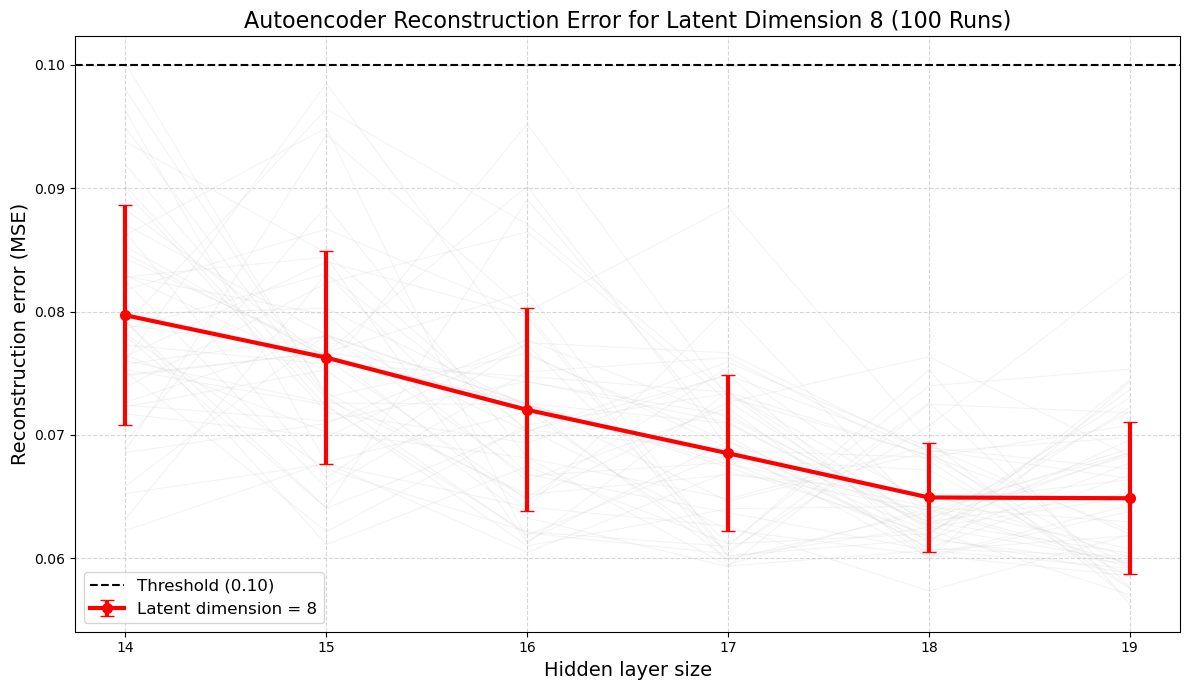

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X = scaler.fit_transform(df).astype("float32")
input_dim = X.shape[1]

tries = 50
latent_dim = 8
capas_int = [14, 15, 16, 17, 18, 19]

# AUTOENCODER


def mse_autoencoder_2_capas(input_dim, capa_int, latent_dim):

    inputs = tf.keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(
        capa_int,
        activation="tanh"
    )(inputs)

    x = layers.Dense(
        latent_dim,
        activation="tanh",
        name="latent"
    )(x)

    # Decoder
    x = layers.Dense(
        capa_int,
        activation="tanh"
    )(x)

    outputs = layers.Dense(
        input_dim,
        activation="linear"
    )(x)

    autoencoder = tf.keras.Model(inputs, outputs)

    autoencoder.compile(
        optimizer="adamW",
        loss="mse"
    )

    autoencoder.fit(
        X,
        X,
        epochs=200,
        batch_size=256,
        shuffle=True,
        verbose=0
    )

    mse = autoencoder.evaluate(
        X,
        X,
        verbose=0
    )

    return mse

# RUN EXPERIMENT

resultados_runs = []
resultados_mean = []
resultados_std = []

for capa in capas_int:

    errores = []

    print(f"Hidden layer = {capa}")

    for t in range(tries):

        mse = mse_autoencoder_2_capas(
            input_dim=input_dim,
            capa_int=capa,
            latent_dim=latent_dim
        )

        errores.append(mse)

    resultados_runs.append(errores)

    resultados_mean.append(
        np.mean(errores)
    )

    resultados_std.append(
        np.std(errores, ddof=1)
    )


# PLOT


plt.figure(figsize=(12,7))

# Individual runs
for run in range(tries):

    ys = [
        resultados_runs[i][run]
        for i in range(len(capas_int))
    ]

    plt.plot(
        capas_int,
        ys,
        color="lightgray",
        alpha=0.25,
        linewidth=0.8
    )

# Mean ± std
plt.errorbar(
    capas_int,
    resultados_mean,
    yerr=resultados_std,
    fmt='o-',
    color='red',
    linewidth=3,
    markersize=7,
    capsize=5,
    label='Latent dimension = 8'
)

# Threshold
plt.axhline(
    y=0.10,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Threshold (0.10)'
)

plt.xlabel(
    "Hidden layer size",
    fontsize=14
)

plt.ylabel(
    "Reconstruction error (MSE)",
    fontsize=14
)

plt.title(
    "Autoencoder Reconstruction Error for Latent Dimension 8 (100 Runs)",
    fontsize=16
)

plt.xticks(capas_int)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

**selecting latent dim** 


Run 1/20

Run 2/20

Run 3/20

Run 4/20

Run 5/20

Run 6/20

Run 7/20

Run 8/20

Run 9/20

Run 10/20

Run 11/20

Run 12/20

Run 13/20

Run 14/20

Run 15/20

Run 16/20

Run 17/20

Run 18/20

Run 19/20

Run 20/20


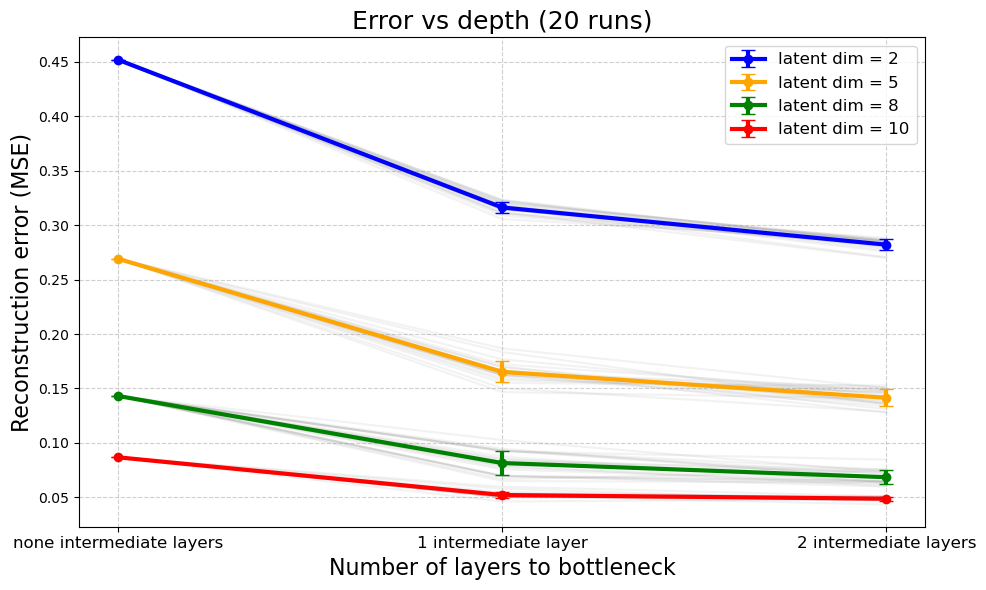

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(df).astype("float32")
input_dim = X.shape[1]

latent_dims = [2, 5, 8, 10]
depths = [1, 2, 3]  # 1=no hidden layer, 2=one, 3=two
tries = 20

epochs = 200
batch_size = 256


# MODEL FUNCTION


def build_autoencoder(input_dim, latent_dim, depth):

    inputs = tf.keras.Input(shape=(input_dim,))
    x = inputs

    # Progressive reduction
    sizes = np.linspace(input_dim, latent_dim, depth + 1)[1:]

    # Encoder
    for s in sizes[:-1]:
        x = layers.Dense(int(s), activation="tanh")(x)

    # Bottleneck
    x = layers.Dense(int(latent_dim), activation="tanh", name="latent")(x)

    # Decoder
    for s in reversed(sizes[:-1]):
        x = layers.Dense(int(s), activation="tanh")(x)

    outputs = layers.Dense(input_dim, activation="linear")(x)

    model = tf.keras.Model(inputs, outputs)
    return model


# EXPERIMENT


# Store results
results = {n: {d: [] for d in depths} for n in latent_dims}

for t in range(tries):
    print(f"\nRun {t+1}/{tries}")

    for latent_dim in latent_dims:
        for depth in depths:

            model = build_autoencoder(input_dim, latent_dim, depth)
            model.compile(optimizer="adamW", loss="mse")

            model.fit(
                X, X,
                epochs=epochs,
                batch_size=batch_size,
                shuffle=True,
                verbose=0
            )

            mse = model.evaluate(X, X, verbose=0)
            results[latent_dim][depth].append(mse)

# COMPUTE STATISTICS

means = {n: [] for n in latent_dims}
stds = {n: [] for n in latent_dims}

for n in latent_dims:
    for d in depths:
        means[n].append(np.mean(results[n][d]))
        stds[n].append(np.std(results[n][d]))

# PLOT

plt.figure(figsize=(10,6))

colors = ["blue", "orange", "green", "red"]

for i, n in enumerate(latent_dims):

    # Individual runs (gray)
    for t in range(tries):
        vals = [results[n][d][t] for d in depths]
        plt.plot(depths, vals, color="gray", alpha=0.1)

    # Mean + std
    plt.errorbar(
        depths,
        means[n],
        yerr=stds[n],
        marker='o',
        linewidth=3,
        capsize=5,
        color=colors[i],
        label=f"latent dim = {n}"
    )

# Labels
plt.xlabel("Number of layers to bottleneck",fontsize=16)
plt.ylabel("Reconstruction error (MSE)",fontsize=16)
plt.title("Error vs depth (20 runs)",fontsize=18)

plt.xticks(depths, ["none intermediate layers", "1 intermediate layer", "2 intermediate layers"],fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()




Run 1/20
Run 2/20
Run 3/20
Run 4/20
Run 5/20
Run 6/20
Run 7/20
Run 8/20
Run 9/20
Run 10/20
Run 11/20
Run 12/20
Run 13/20
Run 14/20
Run 15/20
Run 16/20
Run 17/20
Run 18/20
Run 19/20
Run 20/20


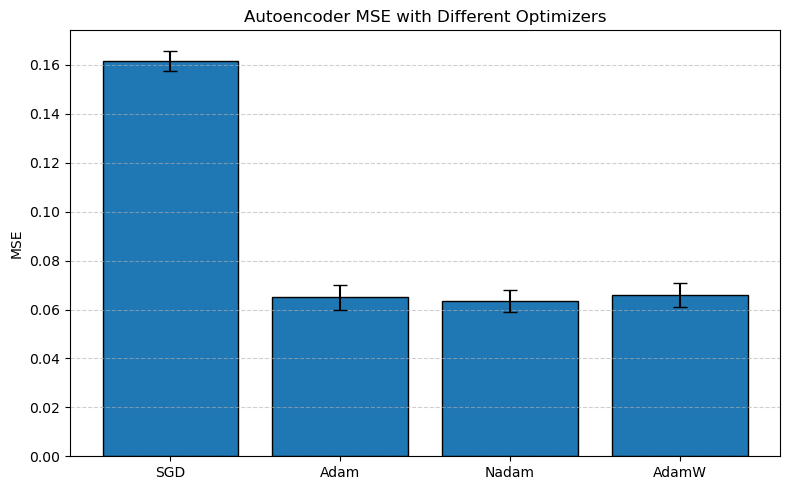

In [5]:
"""
Autoencoder: Optimizer comparison (mean + std across 20 runs)
"""
scaler = StandardScaler()
X = scaler.fit_transform(df).astype("float32")
input_dim = X.shape[1]

latent_dim = 8
capa_int = 19
epochs = 200
batch_size = 256

optimizers = ["SGD", "Adam", "Nadam", "AdamW"]
tries = 20

# Store results
resultados = {opt: [] for opt in optimizers}

# EXPERIMENT

for t in range(tries):
    print(f"Run {t+1}/{tries}")
    
    for opt_name in optimizers:

        # Build autoencoder
        inputs = tf.keras.Input(shape=(input_dim,))
        
        x = layers.Dense(capa_int, activation="tanh")(inputs)

        x = layers.Dense(latent_dim, activation="tanh")(x)

        x = layers.Dense(capa_int, activation="tanh")(x)

        outputs = layers.Dense(input_dim, activation="linear")(x)

        autoencoder = tf.keras.Model(inputs, outputs)

        # Optimizer
        if opt_name == "AdamW":
            optimizer = tf.keras.optimizers.AdamW()
        else:
            optimizer = opt_name.lower()

        autoencoder.compile(optimizer=optimizer, loss="mse")

        # Train
        autoencoder.fit(
            X, X,
            epochs=epochs,
            batch_size=batch_size,
            shuffle=True,
            verbose=0
        )

        # Evaluate
        mse = autoencoder.evaluate(X, X, verbose=0)
        resultados[opt_name].append(mse)

# STATISTICS

media = [np.mean(resultados[opt]) for opt in optimizers]
std = [np.std(resultados[opt]) for opt in optimizers]

# PLOT (BARPLOT WITH ERROR BARS)

plt.figure(figsize=(8,5))

plt.bar(
    optimizers,
    media,
    yerr=std,
    capsize=5,
    edgecolor="black"
)

plt.ylabel("MSE")
plt.title("Autoencoder MSE with Different Optimizers")

plt.grid(axis='y', linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


**Este autoencoder es el bueno**:


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers

# Carga de datos
data = r"C:\Users\belen\OneDrive\Escritorio\TFM ISA\DATA_eCOLI.xlsx"
df = pd.read_excel(data)

latent_dim = 8
capa_int = 19

# Escalado
scaler = StandardScaler() 
X = scaler.fit_transform(df).astype("float32")

# Train / Validation split
X_train, X_val = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

input_dim = X.shape[1]

inputs = tf.keras.Input(shape=(input_dim,))

# Encoder
x = layers.Dense(capa_int, activation="tanh")(inputs)

# Cuello latente
x = layers.Dense(
    latent_dim,
    activation="tanh",
    name="latent"
)(x)

# Decoder
x = layers.Dense(capa_int, activation="tanh")(x)

outputs = layers.Dense(
    input_dim,
    activation="linear"
)(x)

# Modelo
autoencoder = tf.keras.Model(inputs, outputs)

autoencoder.compile(
    optimizer="adamW",
    loss="mse"
)

# Entrenamiento + validación
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=400,
    batch_size=256,
    shuffle=True,
    validation_data=(X_val, X_val),
    verbose=1
)

# Error train
mse_train = autoencoder.evaluate(
    X_train,
    X_train,
    verbose=0
)

# Error validation
mse_val = autoencoder.evaluate(
    X_val,
    X_val,
    verbose=0
)

print(f"MSE train: {mse_train:.5f}")
print(f"MSE validation: {mse_val:.5f}")

Epoch 1/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7548 - val_loss: 0.5280
Epoch 2/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4287 - val_loss: 0.3623
Epoch 3/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3140 - val_loss: 0.2820
Epoch 4/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2544 - val_loss: 0.2346
Epoch 5/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2184 - val_loss: 0.2062
Epoch 6/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1966 - val_loss: 0.1884
Epoch 7/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1822 - val_loss: 0.1762
Epoch 8/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1722 - val_loss: 0.1677
Epoch 9/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1651 - val_loss: 0.1617
Epoch 10/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1600 - val_loss: 0.1575
Epoch 11/400
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1562 - val_loss: 0.1541
Epoch 12/400
103/103 ━━━━━━━━━━━━━━━━━━━━

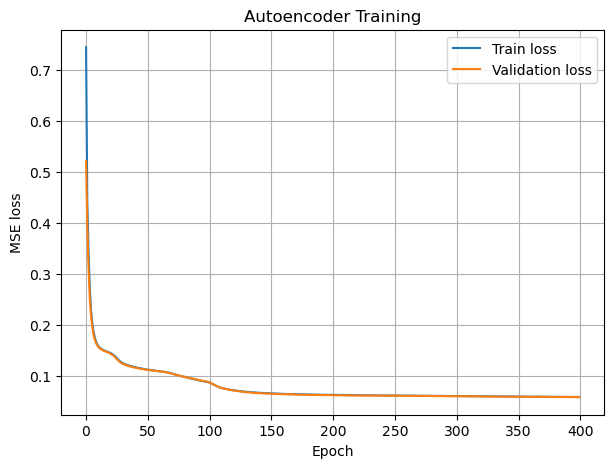

Val loss mínima: 0.05767


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Curvas de entrenamiento
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(7,5))
plt.plot(train_loss, label='Train loss')
plt.plot(val_loss, label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Autoencoder Training')
plt.legend()
plt.grid(True)
plt.show()

print(f"Val loss mínima: {min(val_loss):.5f}")

-- **Using TORCH:** --

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [7]:
data = r"C:\Users\belen\OneDrive\Escritorio\TFM ISA\DATA_eCOLI.xlsx"
df = pd.read_excel(data)

latent_dim = 8
capa_int = 19
batch_size = 256
epochs = 250
learning_rate = 1e-3

**Chose a scale between 1. and 2.**

1. Usual Scale:

In [3]:
scaler = StandardScaler() 
X = scaler.fit_transform(df).astype("float32")
input_dim = X.shape[1]

2. [-1,1] Scale:

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
X= scaler.fit_transform(df)

In [5]:
X_train, X_val = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

input_dim = X.shape[1]

print("X dtype:", X.dtype)
print("X_train dtype:", X_train.dtype)


# TORCH TENSORS

# Use from_numpy instead of torch.tensor
X_train_tensor = torch.from_numpy(X_train).float()
X_val_tensor = torch.from_numpy(X_val).float()

# DataLoaders
train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# DEVICE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# AUTOENCODER

class Autoencoder(nn.Module):

    def __init__(self, input_dim, capa_int, latent_dim):

        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(

            nn.Linear(input_dim, capa_int),
            nn.Tanh(),

            nn.Linear(capa_int, latent_dim),
            nn.Tanh()
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.Linear(latent_dim, capa_int),
            nn.Tanh(),

            nn.Linear(capa_int, input_dim)
        )

    def forward(self, x):

        z = self.encoder(x)

        x_recon = self.decoder(z)

        return x_recon


# MODEL


autoencoder = Autoencoder(
    input_dim=input_dim,
    capa_int=capa_int,
    latent_dim=latent_dim
).to(device)


# LOSS + OPTIMIZER

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    autoencoder.parameters(),
    lr=learning_rate
)

# TRAINING

train_losses = []
val_losses = []

for epoch in range(epochs):

    # TRAIN


    autoencoder.train()

    running_train_loss = 0.0

    for batch in train_loader:

        x_batch = batch[0].to(device)

        optimizer.zero_grad()

        outputs = autoencoder(x_batch)

        loss = criterion(outputs, x_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item() * x_batch.size(0)

    epoch_train_loss = (
        running_train_loss / len(train_loader.dataset)
    )

    # VALIDATION
    

    autoencoder.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for batch in val_loader:

            x_batch = batch[0].to(device)

            outputs = autoencoder(x_batch)

            loss = criterion(outputs, x_batch)

            running_val_loss += loss.item() * x_batch.size(0)

    epoch_val_loss = (
        running_val_loss / len(val_loader.dataset)
    )

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Val Loss: {epoch_val_loss:.6f}"
    )

# FINAL MSE

autoencoder.eval()

with torch.no_grad():

    X_train_device = X_train_tensor.to(device)
    X_val_device = X_val_tensor.to(device)

    train_recon = autoencoder(X_train_device)

    mse_train = criterion(
        train_recon,
        X_train_device
    ).item()

    val_recon = autoencoder(X_val_device)

    mse_val = criterion(
        val_recon,
        X_val_device
    ).item()

print(f"\nMSE train: {mse_train:.6f}")
print(f"MSE validation: {mse_val:.6f}")

X dtype: float64
X_train dtype: float64
Using device: cpu
Epoch [1/250] | Train Loss: 0.299736 | Val Loss: 0.151922
Epoch [2/250] | Train Loss: 0.110133 | Val Loss: 0.081861
Epoch [3/250] | Train Loss: 0.064864 | Val Loss: 0.054141
Epoch [4/250] | Train Loss: 0.047906 | Val Loss: 0.044074
Epoch [5/250] | Train Loss: 0.041897 | Val Loss: 0.039253
Epoch [6/250] | Train Loss: 0.035850 | Val Loss: 0.031715
Epoch [7/250] | Train Loss: 0.029723 | Val Loss: 0.027951
Epoch [8/250] | Train Loss: 0.027091 | Val Loss: 0.026144
Epoch [9/250] | Train Loss: 0.025696 | Val Loss: 0.025058
Epoch [10/250] | Train Loss: 0.024791 | Val Loss: 0.024288
Epoch [11/250] | Train Loss: 0.024085 | Val Loss: 0.023599
Epoch [12/250] | Train Loss: 0.023406 | Val Loss: 0.022871
Epoch [13/250] | Train Loss: 0.022602 | Val Loss: 0.021977
Epoch [14/250] | Train Loss: 0.021708 | Val Loss: 0.021168
Epoch [15/250] | Train Loss: 0.021092 | Val Loss: 0.020708
Epoch [16/250] | Train Loss: 0.020692 | Val Loss: 0.020338
Epoch [

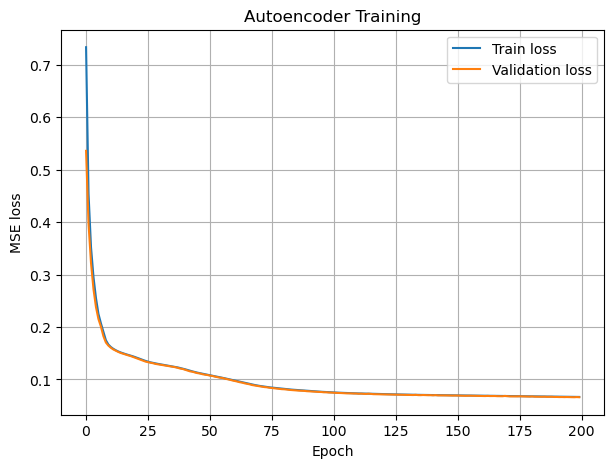

Val loss mínima: 0.06613


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Curvas de entrenamiento
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(7,5))
plt.plot(train_loss, label='Train loss')
plt.plot(val_loss, label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Autoencoder Training')
plt.legend()
plt.grid(True)
plt.show()

print(f"Val loss mínima: {min(val_loss):.5f}")

**Why does the error improve so much when using scaled [-1,1] data VS usual scalation? Calculate relative MSE and absolute errors MAE:**

In [ ]:
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler(feature_range=(-1, 1))

X_std = scaler_std.fit_transform(df).astype("float32")
X_mm  = scaler_mm.fit_transform(df).astype("float32")

# MODEL ARCHITECTURE

class Autoencoder(nn.Module):
    def __init__(self, input_dim, capa_int, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, capa_int),
            nn.Tanh(),
            nn.Linear(capa_int, latent_dim),
            nn.Tanh()
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, capa_int),
            nn.Tanh(),
            nn.Linear(capa_int, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# TRAIN FUNCTION

def train_model(X):

    X_train, X_val = train_test_split(
        X,
        test_size=0.2,
        random_state=42
    )

    train_ds = TensorDataset(torch.from_numpy(X_train))
    val_ds   = TensorDataset(torch.from_numpy(X_val))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = Autoencoder(input_dim, capa_int, latent_dim).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):

        model.train()
        for batch in train_loader:
            x = batch[0].to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, x)
            loss.backward()
            optimizer.step()

    return model, X_val

# EVALUATION FUNCTION 

def evaluate(model, X_val_scaled, scaler):

    model.eval()

    X_tensor = torch.from_numpy(X_val_scaled).float().to(device)

    with torch.no_grad():
        pred_scaled = model(X_tensor).cpu().numpy()

    # back to original scale
    X_true = scaler.inverse_transform(X_val_scaled)
    X_pred = scaler.inverse_transform(pred_scaled)

    # errors
    abs_error = np.abs(X_true - X_pred)
    mse = np.mean((X_true - X_pred) ** 2)
    mae = np.mean(abs_error)

    eps = 1e-8
    rel_error = abs_error / (np.abs(X_true) + eps)
    mre = np.mean(rel_error)

    return mse, mae, mre

# TRAIN BOTH MODELS

model_std, X_val_std = train_model(X_std)
model_mm,  X_val_mm  = train_model(X_mm)

# EVALUATE BOTH MODELS

mse_std, mae_std, mre_std = evaluate(model_std, X_val_std, scaler_std)
mse_mm,  mae_mm,  mre_mm  = evaluate(model_mm,  X_val_mm,  scaler_mm)


results = pd.DataFrame({
    "Scaling": ["StandardScaler", "MinMax(-1,1)"],
    "MSE": [mse_std, mse_mm],
    "MAE": [mae_std, mae_mm],
    "Relative Error": [mre_std, mre_mm]
})

print(results)